# Notebook 05: SHAP Explainability & Feature Attribution Analysis
**Component 1: AI-Based Business Feasibility Analysis and Personalized Business/Growth Plan Recommendation**

---

## Executive Summary & Research Context
Explainable AI (XAI) is a critical requirement for a decision-support system to avoid "black-box" predictions. 
This notebook implements multi-level SHAP (SHapley Additive exPlanations) analysis for the trained Random Forest Feasibility Classifier.




In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Create output figure directory
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models/feasibility_model", exist_ok=True)

print("SHAP Version:", shap.__version__)
print("Setup completed successfully.")


SHAP Version: 0.52.0
Setup completed successfully.


C:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Feature Definition
Loading raw SME feasibility dataset for Colombo District and reproducing exact 70/15/15 train/val/test split.


In [2]:
file_path = "../data/raw/Component_One_Core_Feasibility.csv"
df = pd.read_csv(file_path)

# Separate Target, ID, and Free text
y = df["feasibility_label"]
X = df.drop(columns=["feasibility_label", "case_id", "business_description"])

# Define Categorical and Numerical features
categorical_features = [
    "business_stage", "business_category", "district",
    "province", "location_type", "proposed_action", "competition_level"
]

numerical_features = [
    "available_capital_lkr", "loan_amount_lkr", "monthly_budget_lkr",
    "initial_inventory_cost_lkr", "expected_price_lkr", "expected_customers_per_day",
    "customer_demand_score", "expected_operating_days_per_month",
    "entrepreneur_experience_years", "location_suitability_score",
    "available_staff_count", "required_staff_count",
    "available_equipment_score", "required_equipment_score",
    "supplier_availability_score"
]

# Train (70%), Val (15%), Test (15%) split with random_state=42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Dataset shape: {df.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Dataset shape: (1200, 25)
Training set: 840 samples
Validation set: 180 samples
Testing set: 180 samples


## 2. Preprocessing & Random Forest Model Training
Fitting the exact preprocessing pipeline (`ColumnTransformer` with `StandardScaler` & `OneHotEncoder`) and training the candidate `RandomForestClassifier`.


In [3]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

# Fit on training data
random_forest_model.fit(X_train, y_train)

trained_preprocessor = random_forest_model.named_steps['preprocessor']
trained_rf = random_forest_model.named_steps['classifier']

# Get encoded feature names & transform test set
feature_names = trained_preprocessor.get_feature_names_out()
X_test_processed = trained_preprocessor.transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = np.array(X_test_processed)

print("Trained RF Classes:", trained_rf.classes_)
print(f"Processed Feature Count: {len(feature_names)}")
print(f"Dense X_test Shape: {X_test_dense.shape}")


Trained RF Classes: ['Conditionally Feasible' 'Feasible' 'Infeasible']
Processed Feature Count: 76
Dense X_test Shape: (180, 76)


## 3. Human-Readable Feature Name Mapping
To make SHAP explanations understandable to business stakeholders and entrepreneurs, raw scikit-learn transformer feature names (e.g. `num__available_capital_lkr`, `cat__competition_level_Medium`) are converted to clean, business-friendly terminology.


In [4]:
def clean_feature_name(raw_name):
    name = raw_name.replace("num__", "").replace("cat__", "")
    
    clean_map = {
        "available_capital_lkr": "Available Capital (LKR)",
        "loan_amount_lkr": "Requested Loan Amount (LKR)",
        "monthly_budget_lkr": "Monthly Operating Budget (LKR)",
        "initial_inventory_cost_lkr": "Initial Inventory Cost (LKR)",
        "expected_price_lkr": "Expected Product Price (LKR)",
        "expected_customers_per_day": "Expected Daily Customers",
        "customer_demand_score": "Customer Demand Score (1-100)",
        "expected_operating_days_per_month": "Operating Days / Month",
        "entrepreneur_experience_years": "Entrepreneur Experience (Years)",
        "location_suitability_score": "Location Suitability Score (1-5)",
        "available_staff_count": "Available Staff Count",
        "required_staff_count": "Required Staff Count",
        "available_equipment_score": "Available Equipment Score (1-5)",
        "required_equipment_score": "Required Equipment Score (1-5)",
        "supplier_availability_score": "Supplier Availability Score (1-5)"
    }
    
    for k, v in clean_map.items():
        if name == k:
            return v
        if name.startswith(k + "_"):
            val = name[len(k)+1:]
            return f"{v} = '{val}'"
            
    clean = name.replace("_", " ").title()
    return clean

clean_feature_names = [clean_feature_name(fn) for fn in feature_names]

# Display sample mapping
mapping_sample_df = pd.DataFrame({
    "Raw Feature Name": feature_names[:10],
    "Clean Business Label": clean_feature_names[:10]
})
mapping_sample_df


,Raw Feature Name,Clean Business Label
0,num__available_capital_lkr,Available Capital (LKR)
1,num__loan_amount_lkr,Requested Loan Amount (LKR)
2,num__monthly_budget_lkr,Monthly Operating Budget (LKR)
3,num__initial_inventory_cost_lkr,Initial Inventory Cost (LKR)
4,num__expected_price_lkr,Expected Product Price (LKR)
5,num__expected_customers_per_day,Expected Daily Customers
6,num__customer_demand_score,Customer Demand Score (1-100)
7,num__expected_operating_days_per_month,Operating Days / Month
8,num__entrepreneur_experience_years,Entrepreneur Experience (Years)
9,num__location_suitability_score,Location Suitability Score (1-5)


## 4. SHAP TreeExplainer Computation & Tensor Inspection
Using `shap.TreeExplainer` on the fitted Random Forest classifier.
In SHAP version 0.52.0, multi-class tree explanations return a 3D `Explanation` object where:
- `values.shape` = `(N_samples, N_features, N_classes)`
- Class 0 = `'Conditionally Feasible'`
- Class 1 = `'Feasible'`
- Class 2 = `'Infeasible'`


In [5]:
explainer = shap.TreeExplainer(trained_rf)

# Compute SHAP explanation object for dense test set
shap_explanation = explainer(X_test_dense)
shap_explanation.feature_names = clean_feature_names

class_names = list(trained_rf.classes_)

print("SHAP Explanation Object Type:", type(shap_explanation))
print("SHAP Values Shape (Samples x Features x Classes):", shap_explanation.values.shape)
print("Base Values (Expected Value per class):", explainer.expected_value)


SHAP Explanation Object Type: <class 'shap._explanation.Explanation'>
SHAP Values Shape (Samples x Features x Classes): (180, 76, 3)
Base Values (Expected Value per class): [0.3353631 0.33375   0.3308869]


## 5. Level A: Global SHAP Feature Importance
**Question Answered**: *Which features have the largest overall magnitude impact on feasibility predictions across all classes?*

Global feature importance is computed by taking the mean absolute SHAP value across all samples and classes:
$$\text{Global Importance}_j = \frac{1}{N \cdot K} \sum_{i=1}^N \sum_{k=1}^K |\text{SHAP}_{i,j,k}|$$


C:\Users\DELL\AppData\Local\Temp\ipykernel_19116\894614023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


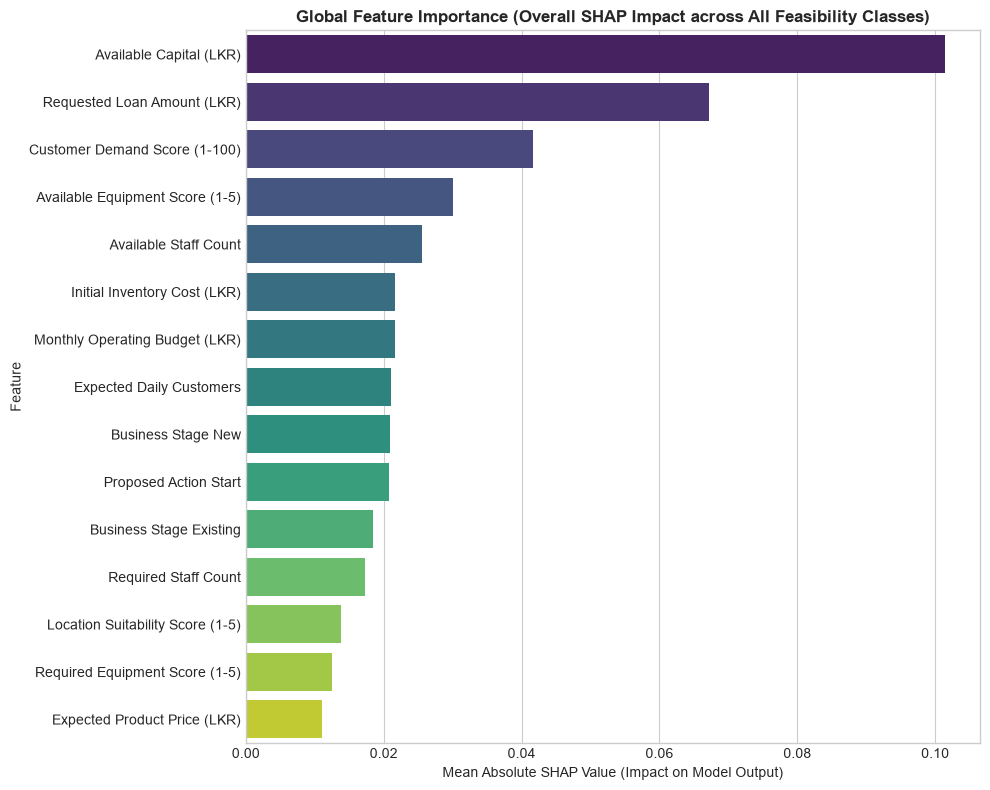

Top 10 Global Features:


,Raw Feature,Feature Name,Mean |SHAP|
0,num__available_capital_lkr,Available Capital (LKR),0.101424
1,num__loan_amount_lkr,Requested Loan Amount (LKR),0.067220
2,num__customer_demand_score,Customer Demand Score (1-100),0.041615
3,num__available_equipment_score,Available Equipment Score (1-5),0.029975
4,num__available_staff_count,Available Staff Count,0.025521
5,num__initial_inventory_cost_lkr,Initial Inventory Cost (LKR),0.021657
6,num__monthly_budget_lkr,Monthly Operating Budget (LKR),0.021621
7,num__expected_customers_per_day,Expected Daily Customers,0.020988
8,cat__business_stage_New,Business Stage New,0.020945
9,cat__proposed_action_start,Proposed Action Start,0.020828


In [6]:
# Compute mean absolute SHAP values across all samples and classes
global_shap_abs = np.mean(np.abs(shap_explanation.values), axis=(0, 2))

# Create Top 20 Global Importance DataFrame
global_importance_df = pd.DataFrame({
    "Raw Feature": feature_names,
    "Feature Name": clean_feature_names,
    "Mean |SHAP|": global_shap_abs
}).sort_values(by="Mean |SHAP|", ascending=False).reset_index(drop=True)

# Plot Global Feature Importance Bar Chart
plt.figure(figsize=(10, 8))
sns.barplot(
    data=global_importance_df.head(15),
    x="Mean |SHAP|",
    y="Feature Name",
    palette="viridis"
)
plt.title("Global Feature Importance (Overall SHAP Impact across All Feasibility Classes)", fontsize=12, fontweight='bold')
plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)")
plt.ylabel("Feature")
plt.tight_layout()

# Save plot
plt.savefig("../reports/figures/05_shap_global_importance.png", dpi=300)
plt.show()

print("Top 10 Global Features:")
global_importance_df.head(10)


## 6. Level B: Class-Specific SHAP Analysis
**Question Answered**: *Which specific factors drive predictions for Feasible, Conditionally Feasible, and Infeasible outcomes?*

We compute class-wise mean absolute SHAP values for each outcome class:
- **Class 0**: `Conditionally Feasible`
- **Class 1**: `Feasible`
- **Class 2**: `Infeasible`


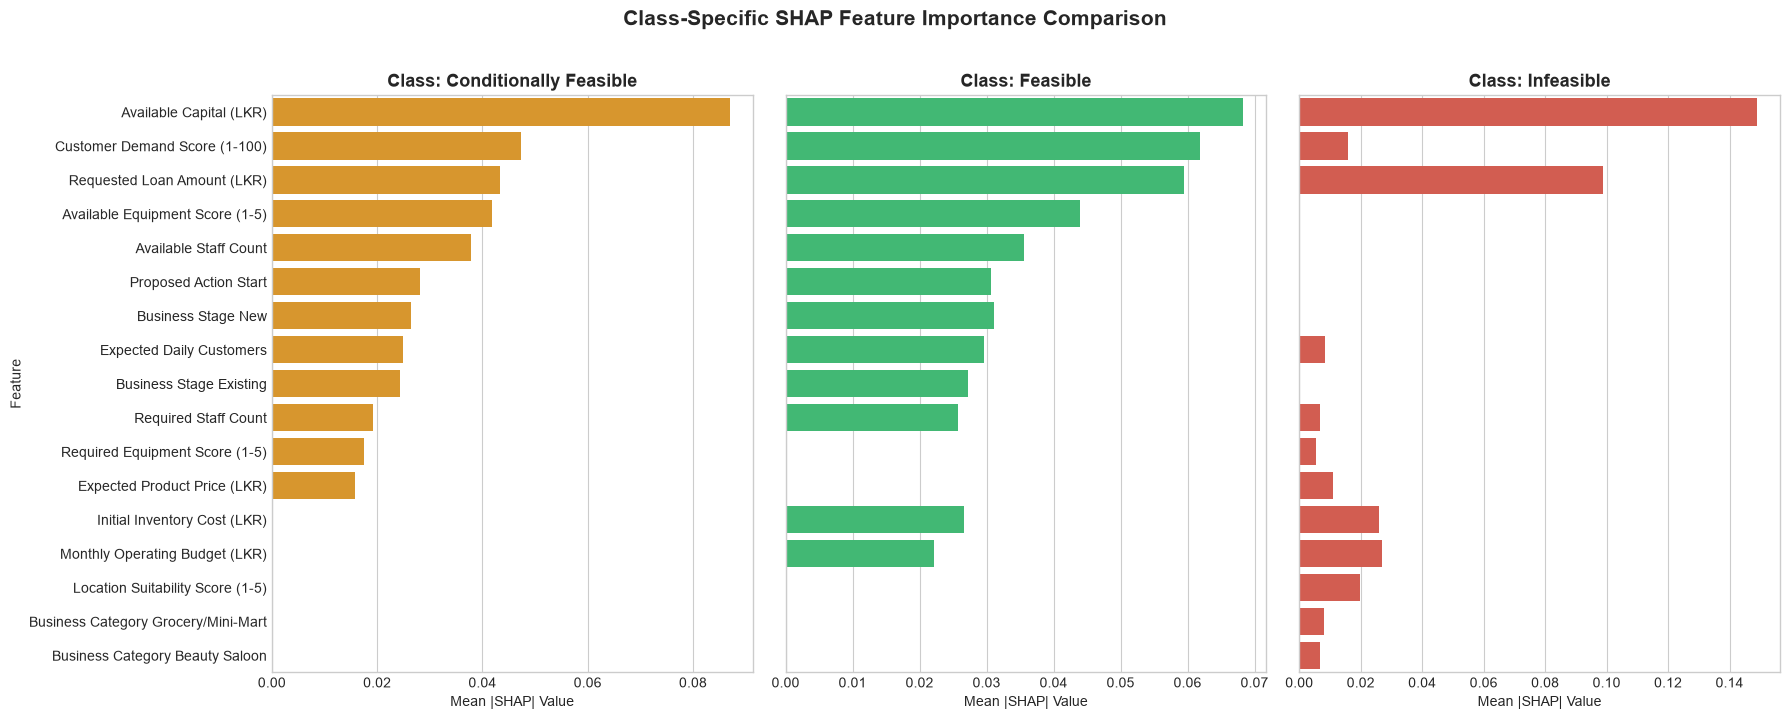

,Feature,Conditionally Feasible,Feasible,Infeasible,Overall_Mean
0,Available Capital (LKR),0.086970,0.068337,0.148965,0.101424
1,Requested Loan Amount (LKR),0.043271,0.059527,0.098861,0.067220
2,Customer Demand Score (1-100),0.047256,0.061816,0.015771,0.041615
3,Available Equipment Score (1-5),0.041723,0.043936,0.004265,0.029975
4,Available Staff Count,0.037857,0.035522,0.003184,0.025521
5,Initial Inventory Cost (LKR),0.012266,0.026632,0.026073,0.021657
6,Monthly Operating Budget (LKR),0.015672,0.022162,0.027029,0.021621
7,Expected Daily Customers,0.024937,0.029563,0.008465,0.020988
8,Business Stage New,0.026491,0.031172,0.005171,0.020945
9,Proposed Action Start,0.028071,0.030643,0.003770,0.020828


In [7]:
# Compute class-specific mean absolute SHAP values
class_shap_df = pd.DataFrame({"Feature": clean_feature_names})

for idx, c_name in enumerate(class_names):
    class_shap_df[c_name] = np.mean(np.abs(shap_explanation.values[:, :, idx]), axis=0)

# Sort by Feasible class impact
class_shap_df["Overall_Mean"] = class_shap_df[class_names].mean(axis=1)
class_shap_df = class_shap_df.sort_values(by="Overall_Mean", ascending=False).reset_index(drop=True)

# Plot Class-wise Feature Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

colors = ["#f39c12", "#2ecc71", "#e74c3c"] # Orange, Green, Red

for idx, (c_name, color) in enumerate(zip(class_names, colors)):
    top_c_df = class_shap_df.sort_values(by=c_name, ascending=False).head(12)
    sns.barplot(
        data=top_c_df,
        x=c_name,
        y="Feature",
        ax=axes[idx],
        color=color
    )
    axes[idx].set_title(f"Class: {c_name}", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel("Mean |SHAP| Value")
    axes[idx].set_ylabel("" if idx > 0 else "Feature")

plt.suptitle("Class-Specific SHAP Feature Importance Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/05_shap_class_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

class_shap_df.head(10)


### Summary Beeswarm Plots for Target Classes
Beeswarm plots illustrate how feature values (high vs low) positively or negatively push prediction probabilities for each class.


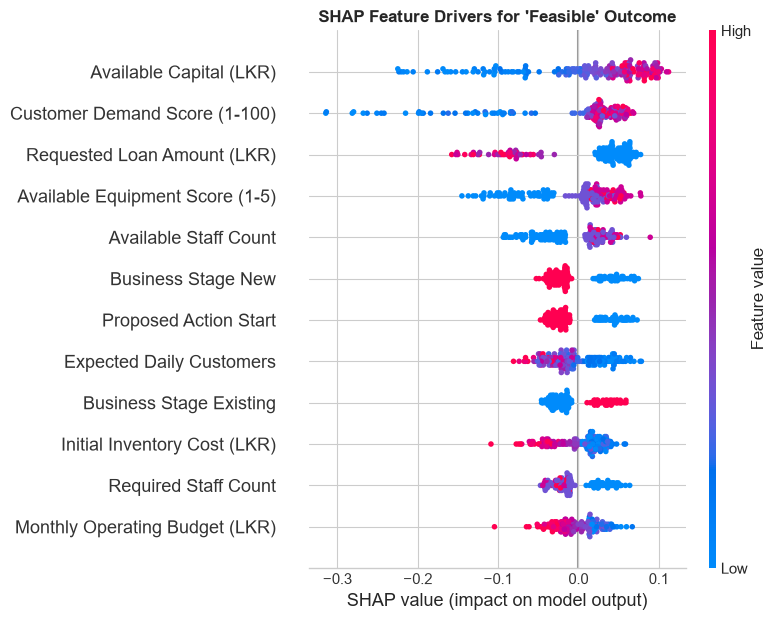

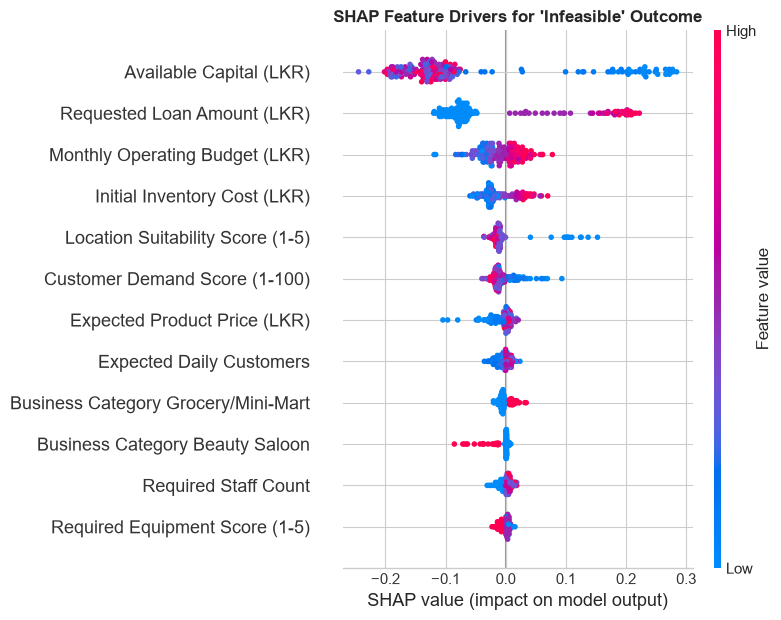

In [8]:
# Generate Beeswarm plot for Class 1 (Feasible)
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Drivers for 'Feasible' Outcome", fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_explanation.values[:, :, 1],
    X_test_dense,
    feature_names=clean_feature_names,
    max_display=12,
    show=False
)
plt.tight_layout()
plt.savefig("../reports/figures/05_shap_beeswarm_feasible.png", dpi=300, bbox_inches='tight')
plt.show()

# Generate Beeswarm plot for Class 2 (Infeasible)
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Drivers for 'Infeasible' Outcome", fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_explanation.values[:, :, 2],
    X_test_dense,
    feature_names=clean_feature_names,
    max_display=12,
    show=False
)
plt.tight_layout()
plt.savefig("../reports/figures/05_shap_beeswarm_infeasible.png", dpi=300, bbox_inches='tight')
plt.show()


## 7. Level C: Local Individual Business Case Explanations
**Question Answered**: *Why did the AI model assign a specific feasibility prediction to a specific business application? What are its key strengths and primary risk factors?*

We select 3 representative business cases from the test dataset:
1. **Case 1**: A High-Confidence **Feasible** Business
2. **Case 2**: A **Conditionally Feasible** Business
3. **Case 3**: An **Infeasible** Business


LOCAL XAI REPORT: FEASIBLE CASE
Predicted Class: Feasible (Probability: 61.0%)
Base Expected Value: 0.3338
--------------------------------------------------
Top Positive Drivers (Supporting Feasibility):
  + Required Equipment Score (1-5) (SHAP Impact: +0.0667)
  + Available Capital (LKR) (SHAP Impact: +0.0633)
  + Customer Demand Score (1-100) (SHAP Impact: +0.0613)
  + Requested Loan Amount (LKR) (SHAP Impact: +0.0576)
  + Required Staff Count (SHAP Impact: +0.0496)

Top Negative Drivers / Risk Factors (Inhibiting Feasibility):
  - Available Equipment Score (1-5) (SHAP Impact: -0.0747)
  - Available Staff Count (SHAP Impact: -0.0260)
  - Proposed Action Start (SHAP Impact: -0.0216)
  - Business Stage New (SHAP Impact: -0.0188)
  - Location Type Polgasowita (SHAP Impact: -0.0182)



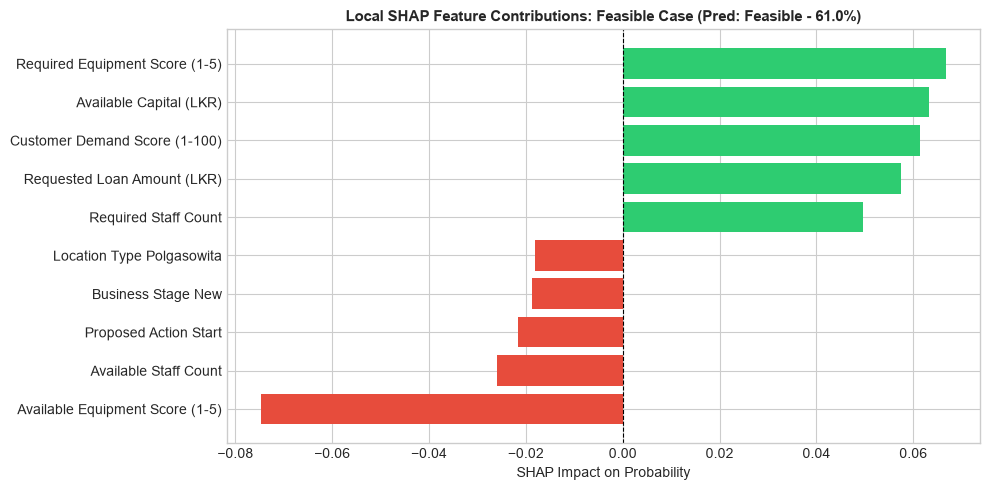

LOCAL XAI REPORT: CONDITIONALLY FEASIBLE CASE
Predicted Class: Conditionally Feasible (Probability: 53.5%)
Base Expected Value: 0.3354
--------------------------------------------------
Top Positive Drivers (Supporting Feasibility):
  + Available Capital (LKR) (SHAP Impact: +0.1717)
  + Available Equipment Score (1-5) (SHAP Impact: +0.0677)
  + Proposed Action Start (SHAP Impact: +0.0196)
  + Business Stage New (SHAP Impact: +0.0179)
  + Business Stage Existing (SHAP Impact: +0.0148)

Top Negative Drivers / Risk Factors (Inhibiting Feasibility):
  - Requested Loan Amount (LKR) (SHAP Impact: -0.0967)
  - Available Staff Count (SHAP Impact: -0.0209)
  - Monthly Operating Budget (LKR) (SHAP Impact: -0.0130)
  - Business Category Grocery/Mini-Mart (SHAP Impact: -0.0090)
  - Location Type Dolahena (SHAP Impact: -0.0053)



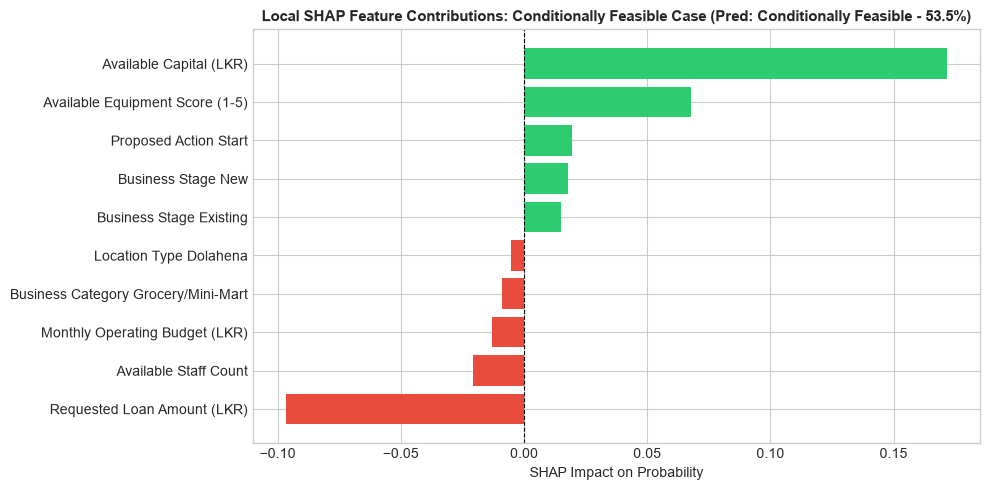

LOCAL XAI REPORT: INFEASIBLE CASE
Predicted Class: Infeasible (Probability: 55.0%)
Base Expected Value: 0.3309
--------------------------------------------------
Top Positive Drivers (Supporting Feasibility):
  + Available Capital (LKR) (SHAP Impact: +0.2287)
  + Requested Loan Amount (LKR) (SHAP Impact: +0.2001)
  + Supplier Availability Score (1-5) (SHAP Impact: +0.0077)
  + Required Staff Count (SHAP Impact: +0.0074)
  + Proposed Action Improve (SHAP Impact: +0.0053)

Top Negative Drivers / Risk Factors (Inhibiting Feasibility):
  - Monthly Operating Budget (LKR) (SHAP Impact: -0.0553)
  - Initial Inventory Cost (LKR) (SHAP Impact: -0.0435)
  - Business Category Beauty Saloon (SHAP Impact: -0.0425)
  - Expected Daily Customers (SHAP Impact: -0.0169)
  - Location Type Bope (SHAP Impact: -0.0132)



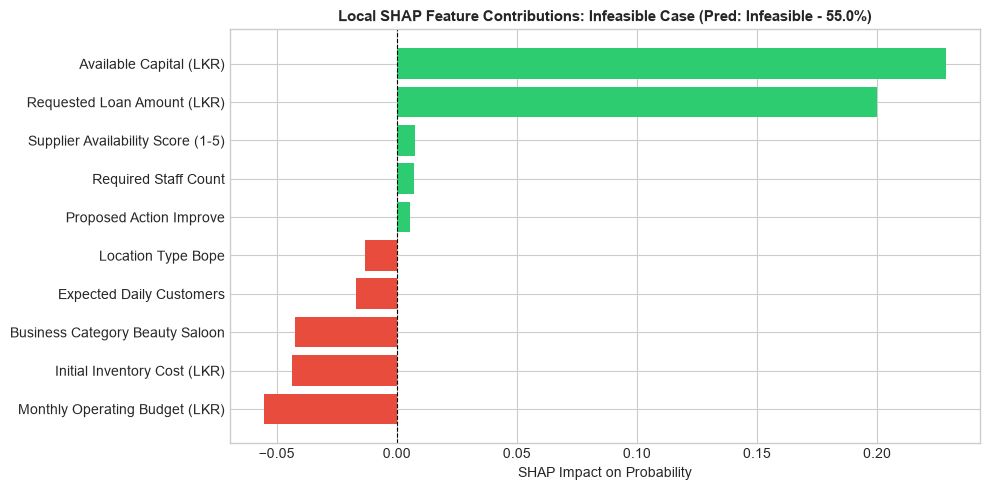

In [9]:
# Get model probabilities on test set
test_probs = trained_rf.predict_proba(X_test_dense)
test_preds = trained_rf.predict(X_test_dense)

test_results_df = X_test.copy()
test_results_df["Actual_Label"] = y_test.values
test_results_df["Predicted_Label"] = test_preds
for i, c_name in enumerate(class_names):
    test_results_df[f"Prob_{c_name}"] = test_probs[:, i]

# Find representative cases
feasible_sample_idx = test_results_df[test_results_df["Predicted_Label"] == "Feasible"].index[0]
cond_sample_idx = test_results_df[test_results_df["Predicted_Label"] == "Conditionally Feasible"].index[0]
infeasible_sample_idx = test_results_df[test_results_df["Predicted_Label"] == "Infeasible"].index[0]

test_loc_feasible = X_test.index.get_loc(feasible_sample_idx)
test_loc_cond = X_test.index.get_loc(cond_sample_idx)
test_loc_infeasible = X_test.index.get_loc(infeasible_sample_idx)

sample_cases = [
    ("Feasible Case", test_loc_feasible, 1),
    ("Conditionally Feasible Case", test_loc_cond, 0),
    ("Infeasible Case", test_loc_infeasible, 2)
]

def generate_local_explanation(case_title, sample_loc, target_class_idx):
    c_name = class_names[target_class_idx]
    pred_prob = test_probs[sample_loc, target_class_idx]
    
    shap_vals_sample = shap_explanation.values[sample_loc, :, target_class_idx]
    base_val = explainer.expected_value[target_class_idx]
    processed_vals = X_test_dense[sample_loc]
    
    # Create Local Feature Importance Table
    local_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "Processed Value": np.round(processed_vals, 3),
        "SHAP Impact": shap_vals_sample
    }).sort_values(by="SHAP Impact", key=abs, ascending=False).reset_index(drop=True)
    
    pos_drivers = local_df[local_df["SHAP Impact"] > 0].head(5)
    neg_drivers = local_df[local_df["SHAP Impact"] < 0].head(5)
    
    print("==================================================")
    print("LOCAL XAI REPORT: " + case_title.upper())
    print("Predicted Class: " + str(c_name) + " (Probability: " + f"{pred_prob:.1%}" + ")")
    print("Base Expected Value: " + f"{base_val:.4f}")
    print("--------------------------------------------------")
    print("Top Positive Drivers (Supporting Feasibility):")
    for _, row in pos_drivers.iterrows():
        print("  + " + str(row['Feature']) + " (SHAP Impact: +" + f"{row['SHAP Impact']:.4f}" + ")")
    print("\nTop Negative Drivers / Risk Factors (Inhibiting Feasibility):")
    for _, row in neg_drivers.iterrows():
        print("  - " + str(row['Feature']) + " (SHAP Impact: " + f"{row['SHAP Impact']:.4f}" + ")")
    print("==================================================\n")

    # Plot Local Bar Chart
    plt.figure(figsize=(10, 5))
    top_local = pd.concat([pos_drivers, neg_drivers]).sort_values(by="SHAP Impact")
    colors_local = ["#e74c3c" if val < 0 else "#2ecc71" for val in top_local["SHAP Impact"]]
    
    plt.barh(top_local["Feature"], top_local["SHAP Impact"], color=colors_local)
    plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"Local SHAP Feature Contributions: {case_title} (Pred: {c_name} - {pred_prob:.1%})", fontsize=11, fontweight='bold')
    plt.xlabel("SHAP Impact on Probability")
    plt.tight_layout()
    plot_filename = f"../reports/figures/05_shap_local_{case_title.lower().replace(' ', '_')}.png"
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()

for title, loc, c_idx in sample_cases:
    generate_local_explanation(title, loc, c_idx)


## 8. Exporting XAI Artifacts & SHAP Metadata
Saving XAI metadata to `models/feasibility_model/shap_metadata.json` for consumption by downstream modules:
- Phase 6: Strategy Generation
- Phase 7: TOPSIS MCDM Strategy Ranking
- Phase 8: Counterfactual & What-If Scenario Analysis
- Application API & Frontend Dashboard


In [10]:
# Compile XAI Metadata
shap_metadata = {
    "shap_version": shap.__version__,
    "classes": class_names,
    "expected_values": [float(v) for v in explainer.expected_value],
    "total_features": len(feature_names),
    "clean_feature_mapping": dict(zip(feature_names, clean_feature_names)),
    "top_global_features": global_importance_df.head(15)[["Raw Feature", "Feature Name", "Mean |SHAP|"]].to_dict(orient="records"),
    "class_specific_drivers": {}
}

for c_name in class_names:
    top_c = class_shap_df.sort_values(by=c_name, ascending=False).head(10)
    shap_metadata["class_specific_drivers"][c_name] = top_c[["Feature", c_name]].to_dict(orient="records")

metadata_path = "../models/feasibility_model/shap_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(shap_metadata, f, indent=4)

print(f"Successfully exported SHAP Metadata to '{metadata_path}'")


Successfully exported SHAP Metadata to '../models/feasibility_model/shap_metadata.json'
